# Kimi K3 — inference roofline

Where does a decode step actually spend its time?

Two numbers per operation, and you wait for the larger:

$$t_{\text{compute}} = \frac{\text{FLOPs}}{\text{peak FLOP/s}} \qquad t_{\text{memory}} = \frac{\text{bytes moved}}{\text{bandwidth}}$$

The ratio of the machine's two peaks is its **balance** — FLOPs per byte it can
sustain. An op above that line is compute bound, below it is memory bound.

Plumbing lives in `roofline.py`; model shapes in `models.py`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from models import K3Config, build
from roofline import GPU, balance_table, build_ops, by_layer, footprint, op_table, summarise
from flops import params_by_hand

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)

COMPUTE, MEMORY = "#2a78d6", "#eb6834"
cfg = K3Config()
model = build(cfg)

## 1. Hand-derived FLOPs vs the loaded model

Same cross-check as the first notebook, so the numbers everything below rests on
are known good. `params_by_hand` uses only config integers; `model.breakdown()`
walks the real module tree.

In [2]:
hand, real = params_by_hand(cfg), model.breakdown()
check = pd.DataFrame({"by hand": hand, "from model": real})
check["diff"] = check["by hand"] - check["from model"]
check.loc["TOTAL"] = [sum(hand.values()), model.total_params(), 0]

print(f"2N by hand     {2 * sum(v for k, v in hand.items() if k != 'Embedding') / 1e9:8.3f} GFLOP/token")
print(f"2N from model  {2 * model.active_params() / 1e9:8.3f} GFLOP/token")
print(f"all buckets agree: {(check['diff'] == 0).all()}")
check

2N by hand     5556.616 GFLOP/token


2N from model   208.375 GFLOP/token
all buckets agree: True


,by hand,from model,diff
KDA,30618086496,30618086496,0
Gated MLA,5572706304,5572706304,0
MoE routed,2722740830208,2722740830208,0
MoE shared,12155092992,12155092992,0
MoE down/up,4726980608,4726980608,0
MoE router,591284736,591284736,0
Dense FFN,726663168,726663168,0
Embedding,1174405120,1174405120,0
Output head,1174405120,1174405120,0
Other,2007040,2007040,0


## 2. Does it even fit?

Before timing anything: the paper serves MoE expert weights in **MXFP4** with
MXFP8 activations, and leaves everything else (attention projections, latent
projections, shared experts, routers) in higher precision (§4.1.4).

That split matters enormously, because the experts are 98% of the parameters.
MXFP4 is 4-bit elements plus one FP8 scale per block of 32, so 4.25 bits each.

In [3]:
fp = footprint(cfg)
print(fp.round(2).to_string())
print(f"\nquantising experts saves {fp['weights all BF16 (GB)'] - fp['weights MXFP4+BF16 (GB)']:,.0f} GB")
print(f"still needs {np.ceil(fp['GPUs to hold weights']):.0f} GPUs just to hold the weights,")
print("so everything below is per-GPU time for a model that is really sharded.")

expert params (B)          2722.74
other params (B)             56.74
weights MXFP4+BF16 (GB)    1559.94
weights all BF16 (GB)      5558.96
one GPU HBM (GB)            309.24
GPUs to hold weights          5.04

quantising experts saves 3,999 GB
still needs 6 GPUs just to hold the weights,
so everything below is per-GPU time for a model that is really sharded.


## 3. Per-operation: work, traffic, and both bounds

One row per kernel an inference engine actually launches, with everything needed
to say what limits it.

**Arithmetic intensity** is the ratio that decides it:

$$I = \frac{\text{FLOPs for the op}}{\text{bytes shuttled from DRAM}} \qquad [\text{FLOP}/\text{byte}]$$

Compare it against the **machine balance**, `peak FLOP/s ÷ bandwidth`, which is
how much arithmetic the GPU can do per byte it can fetch. Above the balance the
op is compute bound; below it, memory bound. Equivalently just take the larger of
the two times — same answer.

The two bounds, spelled out:

| column | formula | what it means |
|---|---|---|
| `COMPUTE <prec> (us)` | `FLOPs / peak_flops(prec)` | how long the math alone would take |
| `MEMORY (us)` | `bytes / bandwidth` | how long the DRAM traffic alone would take |
| `limited by` | argmax of the two | what you actually wait for |

Three precisions are shown for the compute bound so you can see what quantising
further would buy. **Bytes are held fixed across the three** — this asks "if the
arithmetic ran faster, would it help?", not "what if we requantised the weights",
which would change the traffic too.

Three ops are not plain GEMMs:

- **`moe.experts`** — bytes scale with the number of *distinct* experts the batch
  wakes, FLOPs with `k=16`. One token wakes 16 of 896; a big batch wakes nearly all.
- **`mla.attn`** — no weights. Streams the whole KV cache, so bytes grow with context.
- **`kda.recurrence`** — no weights. Fixed-size state, so cost is flat in context.

### The hardware numbers

`GPU()` is the **GB300 NVL72 bin**, per Blackwell Ultra GPU, all **dense** (no
2:4 sparsity). From NVIDIA's own pages:

| | value | note |
|---|---|---|
| HBM3e | 288 GB | per GPU, stated directly |
| bandwidth | 8 TB/s | per GPU (rack 576 TB/s ÷ 72) |
| NVFP4 | 15 PFLOP/s | dense; sparse is 20, **not** 30 |
| FP8 | 5 PFLOP/s | dense |
| BF16 | 2.5 PFLOP/s | derived: rack 360 PF sparse ÷ 2 ÷ 72 |

Two traps worth knowing. **Most published tensor-core figures are sparse** — the
rack pages say so in a footnote — so halving is usually right, *except* for FP4 on
Blackwell Ultra, where dense|sparse is 15|20 rather than 15|30. Halving the sparse
20 gives 10 PF, which is B200's dense rate, not B300's.

And **Blackwell Ultra only raised FP4.** NVFP4 dense went 10 → 15 PF/GPU, while
FP8, BF16 and TF32 stayed exactly at B200 rates (INT8 and FP64 were cut ~30x).
So the gap between the compute columns below is narrower than the "each precision
doubles" rule of thumb suggests: bf16 → fp8 is 2x, but fp8 → mxfp4 is 3x.

`hgx_b300()` gives the air-cooled bin (~10% lower) if you want to compare.

In [4]:
BATCH, SEQ = 1, 131_072
hw = GPU()
ops = build_ops(cfg, batch=BATCH, seq=SEQ, hw=hw)

print(f"{hw.name}")
print(f"  bandwidth {hw.bandwidth / 1e12:.1f} TB/s   "
      f"peak {', '.join(f'{k} {v / 1e15:.1f} PFLOP/s' for k, v in hw.peak.items())}")
print("\nmachine balance -- FLOP/byte needed to keep the tensor cores fed:")
print(balance_table(hw).round(0).to_string())
print(f"\nbatch {BATCH}, context {SEQ:,}\n")

op_table(ops, hw).round(2)

GB300 NVL72 (per B300 GPU)
  bandwidth 8.0 TB/s   peak bf16 2.5 PFLOP/s, fp8 5.0 PFLOP/s, mxfp4 15.0 PFLOP/s

machine balance -- FLOP/byte needed to keep the tensor cores fed:
bf16 (FLOP/byte)      312.0
fp8 (FLOP/byte)       625.0
mxfp4 (FLOP/byte)    1875.0

batch 1, context 131,072



,group,GFLOP,GB from DRAM,intensity (FLOP/byte),COMPUTE bf16 (us),COMPUTE fp8 (us),COMPUTE mxfp4 (us),MEMORY (us),limited by
op,,,,,,,,,
kda.qkv_proj,KDA,36.47,36.47,1.00,14.59,7.29,2.43,4558.92,memory
moe.experts,MoE,97.24,25.85,3.76,38.90,19.45,6.48,3231.05,memory
moe.shared,MoE,24.31,24.31,1.00,9.72,4.86,1.62,3039.36,memory
kda.gate,KDA,12.16,12.16,1.00,4.86,2.43,0.81,1519.72,memory
kda.out,KDA,12.16,12.16,1.00,4.86,2.43,0.81,1519.72,memory
moe.w_up,MoE,4.73,4.73,1.00,1.89,0.95,0.32,591.12,memory
moe.w_down,MoE,4.73,4.73,1.00,1.89,0.95,0.32,591.12,memory
mla.out,MLA,4.23,4.23,1.00,1.69,0.85,0.28,528.60,memory
mla.gate,MLA,4.23,4.23,1.00,1.69,0.85,0.28,528.60,memory


### Does more compute help?

Sum the columns. This is the whole answer to the roofline question.

In [5]:
tbl = op_table(ops, hw)
tot = tbl[["COMPUTE bf16 (us)", "COMPUTE fp8 (us)", "COMPUTE mxfp4 (us)", "MEMORY (us)"]].sum()

print(f"memory bound      {tot['MEMORY (us)'] / 1e3:8.2f} ms")
for p in ["bf16", "fp8", "mxfp4"]:
    c = tot[f"COMPUTE {p} (us)"]
    print(f"compute bound @ {p:<6}{c / 1e3:7.3f} ms   ({tot['MEMORY (us)'] / c:5.0f}x under the memory bound)")

print(f"\nwhole-step intensity  {ops.flops.sum() / ops.bytes.sum():.2f} FLOP/byte")
print(f"machine balance bf16  {hw.balance['bf16']:.0f} FLOP/byte")
print(f"\n{(tbl['limited by'] == 'memory').sum()} of {len(tbl)} operations are memory bound;"
      f" {(tbl['limited by'] == 'compute').sum()} are compute bound.")

memory bound         17.37 ms
compute bound @ bf16    0.160 ms   (  109x under the memory bound)
compute bound @ fp8     0.080 ms   (  217x under the memory bound)
compute bound @ mxfp4   0.027 ms   (  651x under the memory bound)

whole-step intensity  2.88 FLOP/byte
machine balance bf16  312 FLOP/byte

19 of 19 operations are memory bound; 0 are compute bound.


## 5. Runtime per layer

Per operation take `max(t_compute, t_memory)` — the resource that op waits on —
then sum those within a layer.

Caveat worth stating: this assumes ops run back to back and each saturates one
resource alone. Real kernels fuse and overlap, so read this as a floor on time,
not a prediction.

In [6]:
layers = by_layer(ops)
print(layers.round(2).to_string())
print()
print(summarise(ops, hw).round(3).to_string())

       instances  t_1layer_us  t_total_ms  compute-bound ops  memory-bound ops
group                                                                         
KDA         69.0       111.71        7.71                0.0               7.0
MoE         92.0        82.61        7.60                0.0               5.0
MLA         24.0        73.80        1.77                0.0               6.0
Head         1.0       293.64        0.29                0.0               1.0
MODEL      186.0          NaN       17.37                0.0              19.0

TFLOP / token               0.400
GB moved / token          138.986
arithmetic intensity        2.880
machine balance (bf16)    312.500
t_compute (ms)              0.128
t_memory (ms)              17.373
t_total (ms)               17.373
tokens/s (1 GPU)           57.560


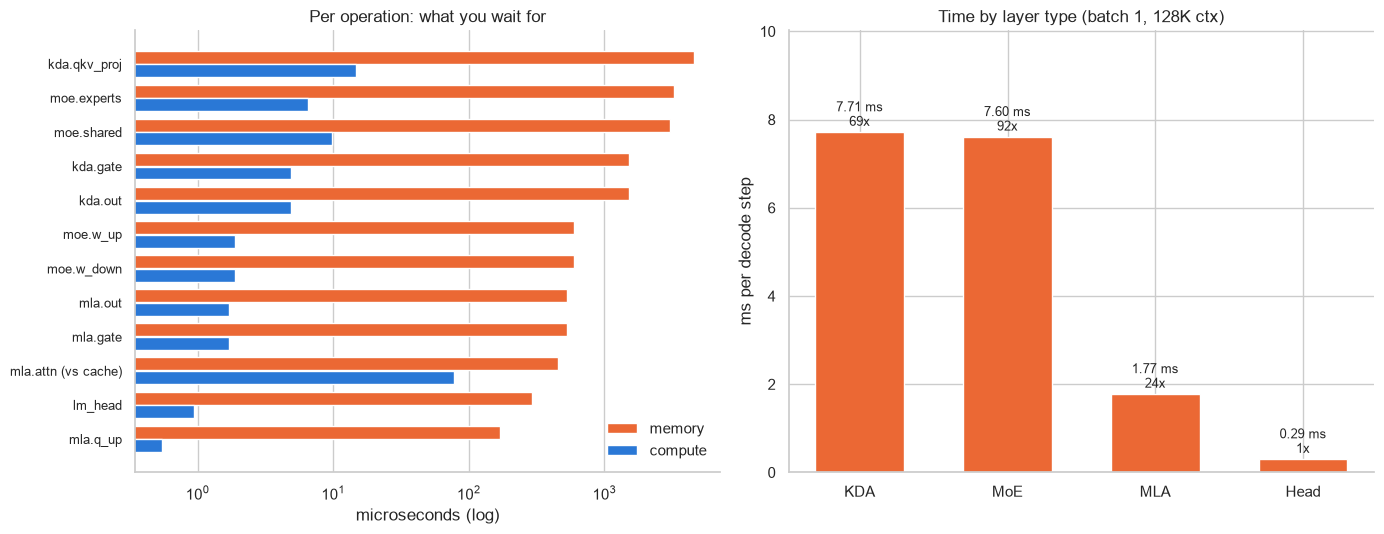

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

top = ops.head(12).iloc[::-1]
y = np.arange(len(top))
ax1.barh(y + 0.2, top.t_memory * 1e6, 0.38, color=MEMORY, label="memory")
ax1.barh(y - 0.2, top.t_compute * 1e6, 0.38, color=COMPUTE, label="compute")
ax1.set_yticks(y, top.index, fontsize=9)
ax1.set_xscale("log")
ax1.set_xlabel("microseconds (log)")
ax1.set_title("Per operation: what you wait for")
ax1.legend(frameon=False, loc="lower right")
ax1.grid(axis="y", visible=False)

lay = layers.drop("MODEL")
ax2.bar(lay.index, lay.t_total_ms, color=[MEMORY] * len(lay), width=0.6)
for i, (n, r) in enumerate(lay.iterrows()):
    ax2.text(i, r.t_total_ms + 0.15, f"{r.t_total_ms:.2f} ms\n{int(r.instances)}x",
             ha="center", fontsize=9)
ax2.set_ylabel("ms per decode step")
ax2.set_title(f"Time by layer type (batch {BATCH}, {SEQ // 1024}K ctx)")
ax2.set_ylim(0, lay.t_total_ms.max() * 1.3)

sns.despine()
plt.tight_layout()

## 6. Why it is all memory bound, and what fixes it

Arithmetic intensity of the whole step is ~3 FLOP/byte. The GB300 can sustain
~312 FLOP/byte in bf16. Off by a factor of ~100, so the tensor cores idle while
HBM streams weights.

That is not a K3 problem, it is what batch-1 decode *is*: every weight is read to
produce a single token. The fix is batching — read the weight once, use it for
`B` tokens — which multiplies FLOPs by `B` while bytes stay flat.

Except MoE breaks that, which is the interesting part.

In [8]:
from roofline import experts_touched

rows = []
for b in [1, 4, 16, 64, 256, 1024]:
    o = build_ops(cfg, batch=b, seq=SEQ, hw=hw)
    t = o[["flops", "bytes", "t_compute", "t_memory"]].sum()
    rows.append({
        "batch": b,
        "experts woken": experts_touched(cfg.n_routed, cfg.n_active_routed, b),
        "TFLOP": t.flops / 1e12,
        "GB moved": t.bytes / 1e9,
        "intensity": t.flops / t.bytes,
        "ms/step": max(t.t_compute, t.t_memory) * 1e3,
        "tok/s": b / max(t.t_compute, t.t_memory),
    })

scale = pd.DataFrame(rows).set_index("batch")
scale.round(2)

,experts woken,TFLOP,GB moved,intensity,ms/step,tok/s
batch,,,,,,
1,16.00,0.40,138.99,2.88,17.37,57.56
4,62.31,1.60,226.06,7.08,28.26,141.56
16,224.41,6.40,537.03,11.92,67.13,238.35
64,613.20,25.61,1361.75,18.81,170.22,375.99
256,887.11,102.46,2592.31,39.52,324.04,790.03
1024,896.00,409.82,5760.16,71.15,720.02,1422.18


**Read the `experts woken` column against `GB moved`.**

A dense model batches for free: the weights are the same bytes no matter how many
tokens you push through, so intensity rises linearly with batch and you walk up
to the compute roof.

K3 does not get that. At batch 1 you read 16 experts per layer. By batch 256 the
batch collectively selects nearly all 896, so you are streaming the entire expert
bank to serve one step — the bytes grow almost as fast as the FLOPs and intensity
stalls. This is the central problem in MoE serving, and it is why expert
parallelism and routing locality get as much engineering attention as the kernels
do.